### Rotina disponibilizada no site da OPEN-METEO para baixar variáveis atmosféricas

In [13]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt

In [14]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": -23.6473149,
	"longitude": -46.6643635,
	"start_date": "2013-01-01",
	"end_date": "2019-12-31",
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"],
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)

Coordinates: -23.655536651611328°N -46.7088623046875°E
Elevation: 793.0 m asl
Timezone difference to GMT+0: 0s


In [15]:
# ORGANIZA DATAFRAME
hourly_dataframe = hourly_dataframe.rename(columns={"date": "time"})

# converter UTC para horário local de São Paulo
hourly_dataframe["time"] = (
    pd.to_datetime(hourly_dataframe["time"], utc=True)
    .dt.tz_convert("America/Sao_Paulo")
)

hourly_dataframe = hourly_dataframe.set_index("time")
hourly_dataframe = hourly_dataframe.sort_index()

In [16]:
# SALVAR CSV
#arquivo_saida = "../data/open_meteo/openmeteo_historico_2013_2019.csv"

#hourly_dataframe.to_csv(
#    arquivo_saida,
#    encoding="utf-8"
#)

#print(f"Arquivo salvo: {arquivo_saida}")

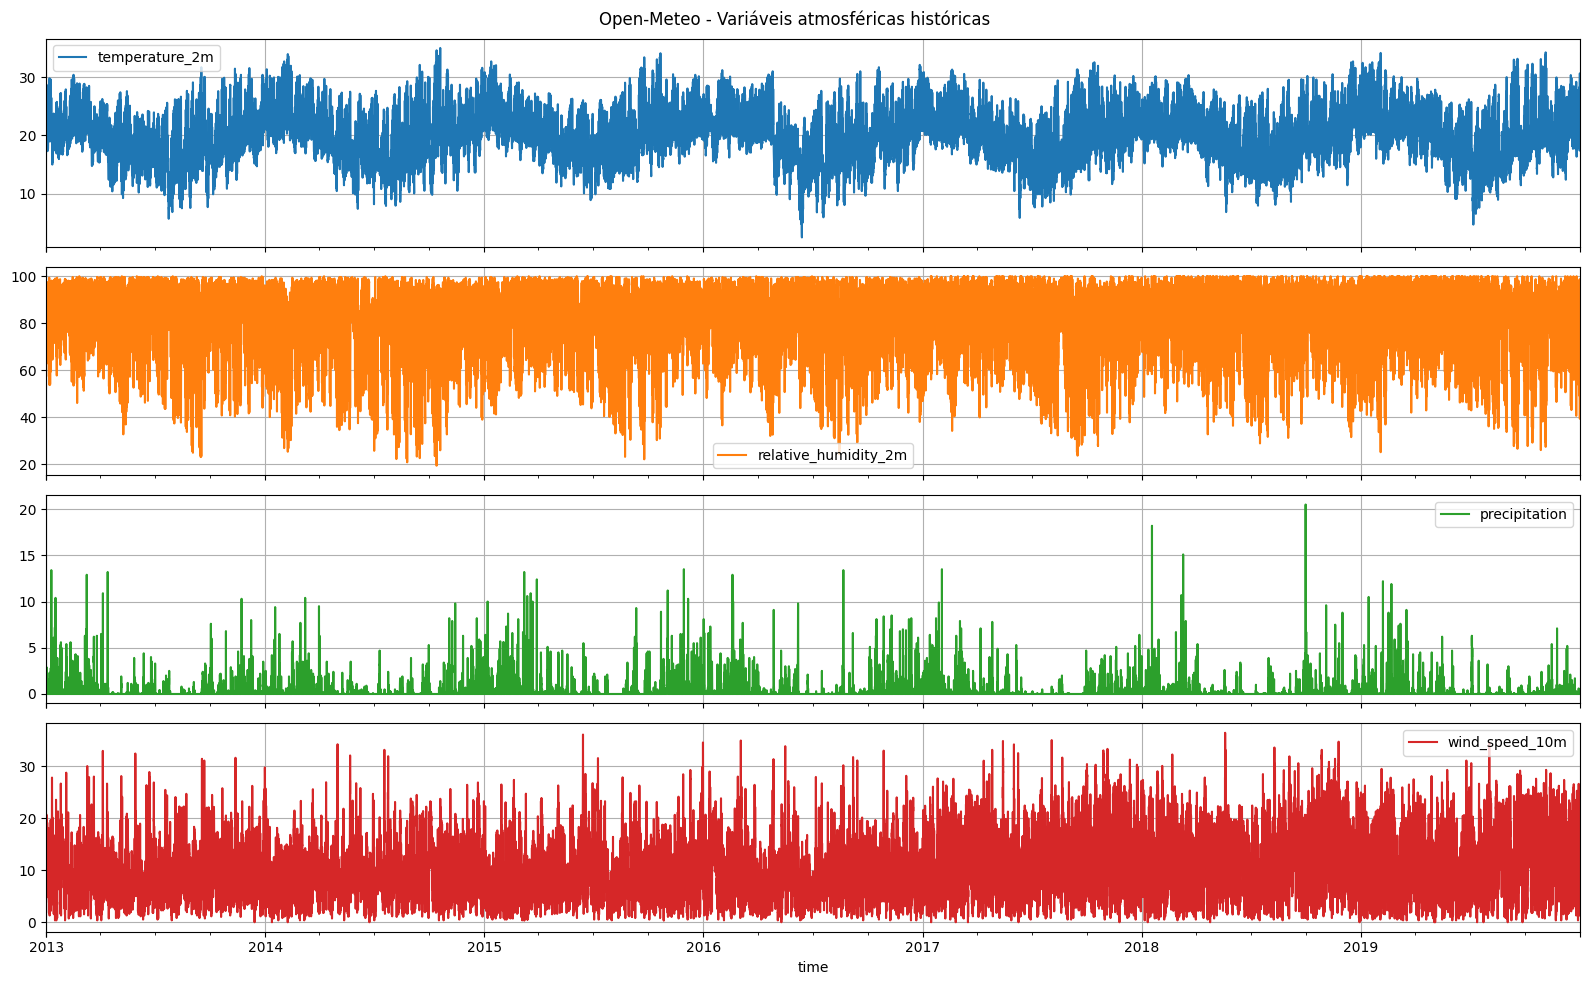

In [17]:
# PLOTAR TODAS AS VARIÁVEIS
hourly_dataframe.plot(
    figsize=(16, 10),
    subplots=True,
    sharex=True,
    grid=True,
    title="Open-Meteo - Variáveis atmosféricas históricas"
)

plt.tight_layout()
plt.show()

### Previsão

In [18]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": -23.6473149,
	"longitude": -46.6643635,
	"hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation_probability"],
	"forecast_days": 1,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["precipitation_probability"] = hourly_precipitation_probability

hourly_dataframe = pd.DataFrame(data = hourly_data)


Coordinates: -23.655536651611328°N -46.7088623046875°E
Elevation: 793.0 m asl
Timezone difference to GMT+0: 0s


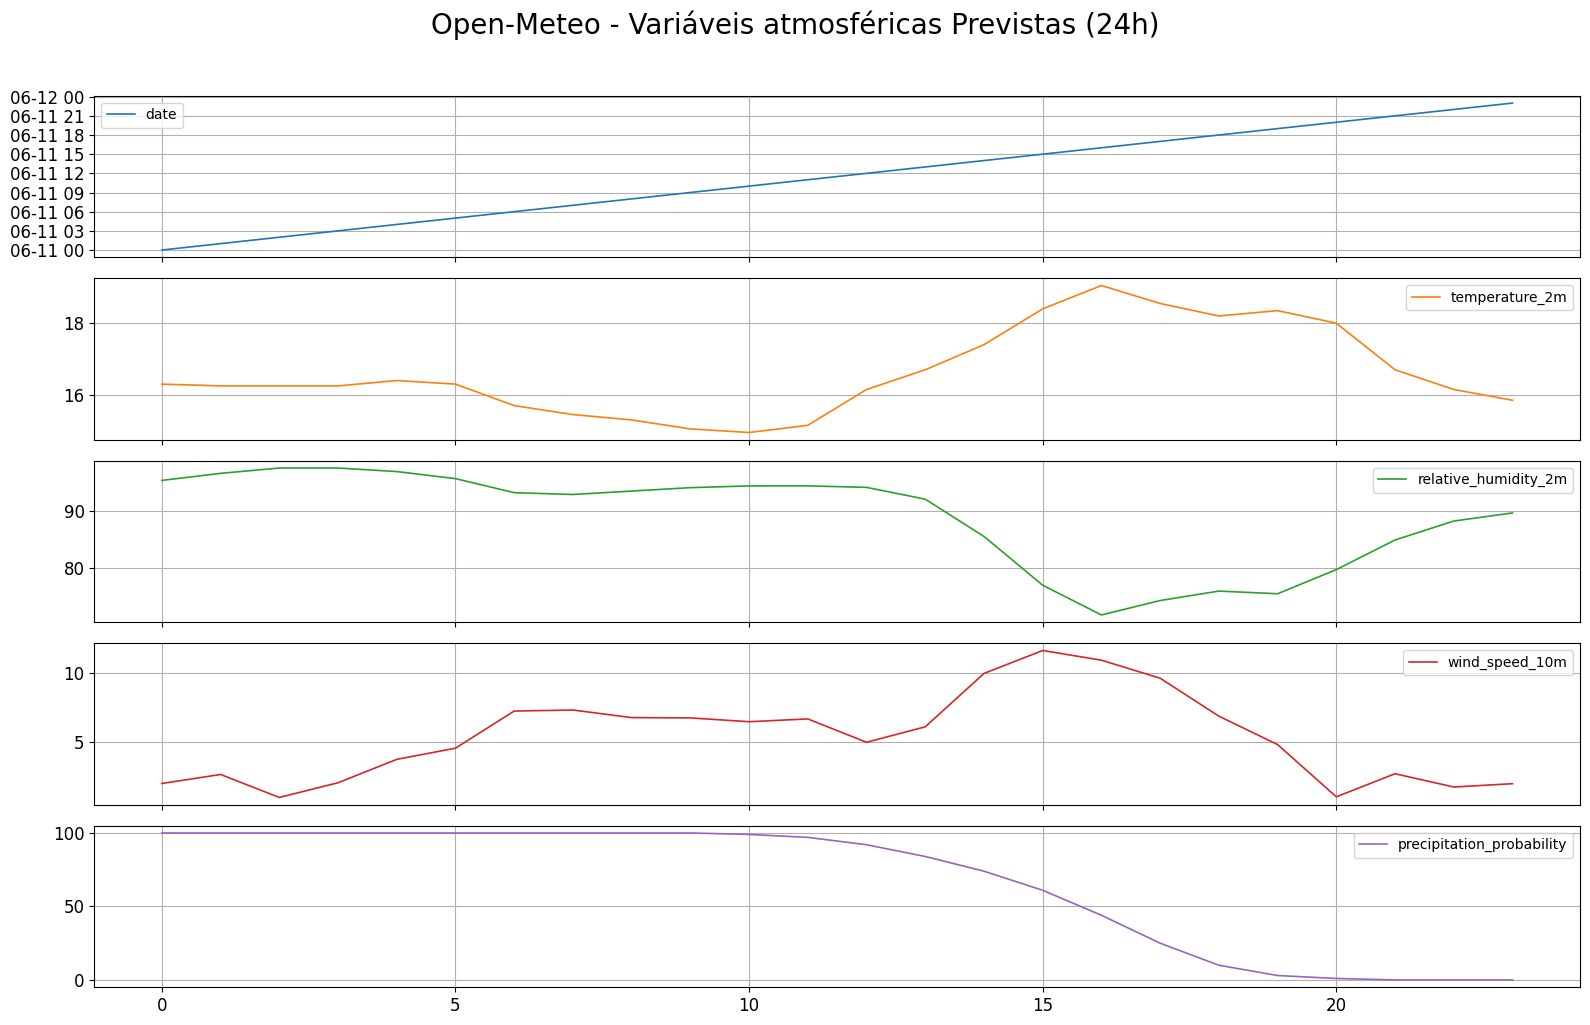

In [ ]:
# PLOTA VARIÁVEIS
axes = hourly_dataframe.plot(
    figsize=(16, 10),
    subplots=True,
    sharex=True,
    grid=True,
    linewidth=1.2,
    fontsize=12
)


plt.suptitle(
    "Open-Meteo - Variáveis atmosféricas Previstas (24h)",
    fontsize=20,
    y=1.02
)


for ax in axes:


    ax.set_title(
        ax.get_title(),
        fontsize=16
    )


    ax.set_ylabel(
        ax.get_ylabel(),
        fontsize=14
    )

    ax.set_xlabel(
        ax.get_xlabel(),
        fontsize=14
    )


    ax.tick_params(
        axis='both',
        labelsize=12
    )

plt.tight_layout()
plt.show()